In [2]:
from nba_api.stats.endpoints import leaguegamefinder
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.pyplot import Axes
import os
from PIL import Image
from pathlib import Path

csv_dir = 'csvs'

# Pull data from the 2025-2026 NBA season
games_26 = leaguegamefinder.LeagueGameFinder(season_nullable='2025-26', season_type_nullable='Regular Season')
# get data frame from returned list
df_26: pd.DataFrame = games_26.get_data_frames()[0]
# Write data to csv for easier viewing. Not necessary
df_26.to_csv(os.path.join(csv_dir,'25_26_season_raw_data.csv') ,index=False)

In [ ]:
# 2025-26
team_stats_26 = df_26[['SEASON_ID','TEAM_ABBREVIATION', 'PTS', 'WL']]
# Change Season ID Value
team_stats_26['SEASON_ID'] = '2025-26'
# Write to csv for easy viewing
team_stats_26.to_csv(os.path.join(csv_dir,'26_season_filtered_points.csv'), index=False)

In [50]:
# Aggregating Game data based off of the game ID
game_stats = df_26[['TEAM_ABBREVIATION', 'GAME_ID', 'MATCHUP' , 'WL', 'PTS' ]]
# New Names
name_dict = {
    'TEAM_ABBREVIATION': 'team',
    'GAME_ID': 'gameid',
    'MATCHUP': 'opp',
    'PTS': 'points',
}
game_stats = game_stats.rename(columns=name_dict)
game_stats['home/away'] = game_stats["opp"].apply(lambda x: "away" if "@" in x else "home")
game_stats['opp'] = game_stats['opp'].str[-3:]
print(game_stats.head())

  team      gameid  opp WL  points home/away
0  BKN  0022501192  TOR  L     101      away
1  NYK  0022501190  CHA  L      96      home
2  POR  0022501200  SAC  W     122      home
3  PHX  0022501196  OKC  W     135      away
4  MEM  0022501194  HOU  L     101      away


In [27]:
# Repeating the same steps performed previously, but for the 2025-26 season.
overall_avg = (
    team_stats_26.groupby('TEAM_ABBREVIATION')
    .agg(
        points=('PTS', 'mean'),
    )
).reset_index()

overall_avg.to_csv(os.path.join(csv_dir,'overall_avg.csv'), index=False)

# Filter Data frame for just the wins of each team
wins_data = team_stats_26[team_stats_26['WL'] == 'W']

league_win_avg = sum(wins_data['PTS'])/len(wins_data['PTS'])

print(league_win_avg)
# Aggregate the Wins Data
wins_agg = (
    wins_data.groupby('TEAM_ABBREVIATION')
    .agg(
        points=('PTS', 'mean'),
        wins=('WL', lambda s: (s=='W').sum())
    )
).reset_index()
wins_agg = wins_agg.rename(columns={'TEAM_ABBREVIATION':'teams'})
print(wins_agg.head())
wins_agg.to_csv(os.path.join(csv_dir,'wins_avg.csv'), index=False)

122.24471544715448
  teams      points  wins
0   ATL  123.521739    46
1   BKN  116.300000    20
2   BOS  120.446429    56
3   CHA  121.795455    44
4   CHI  125.000000    31


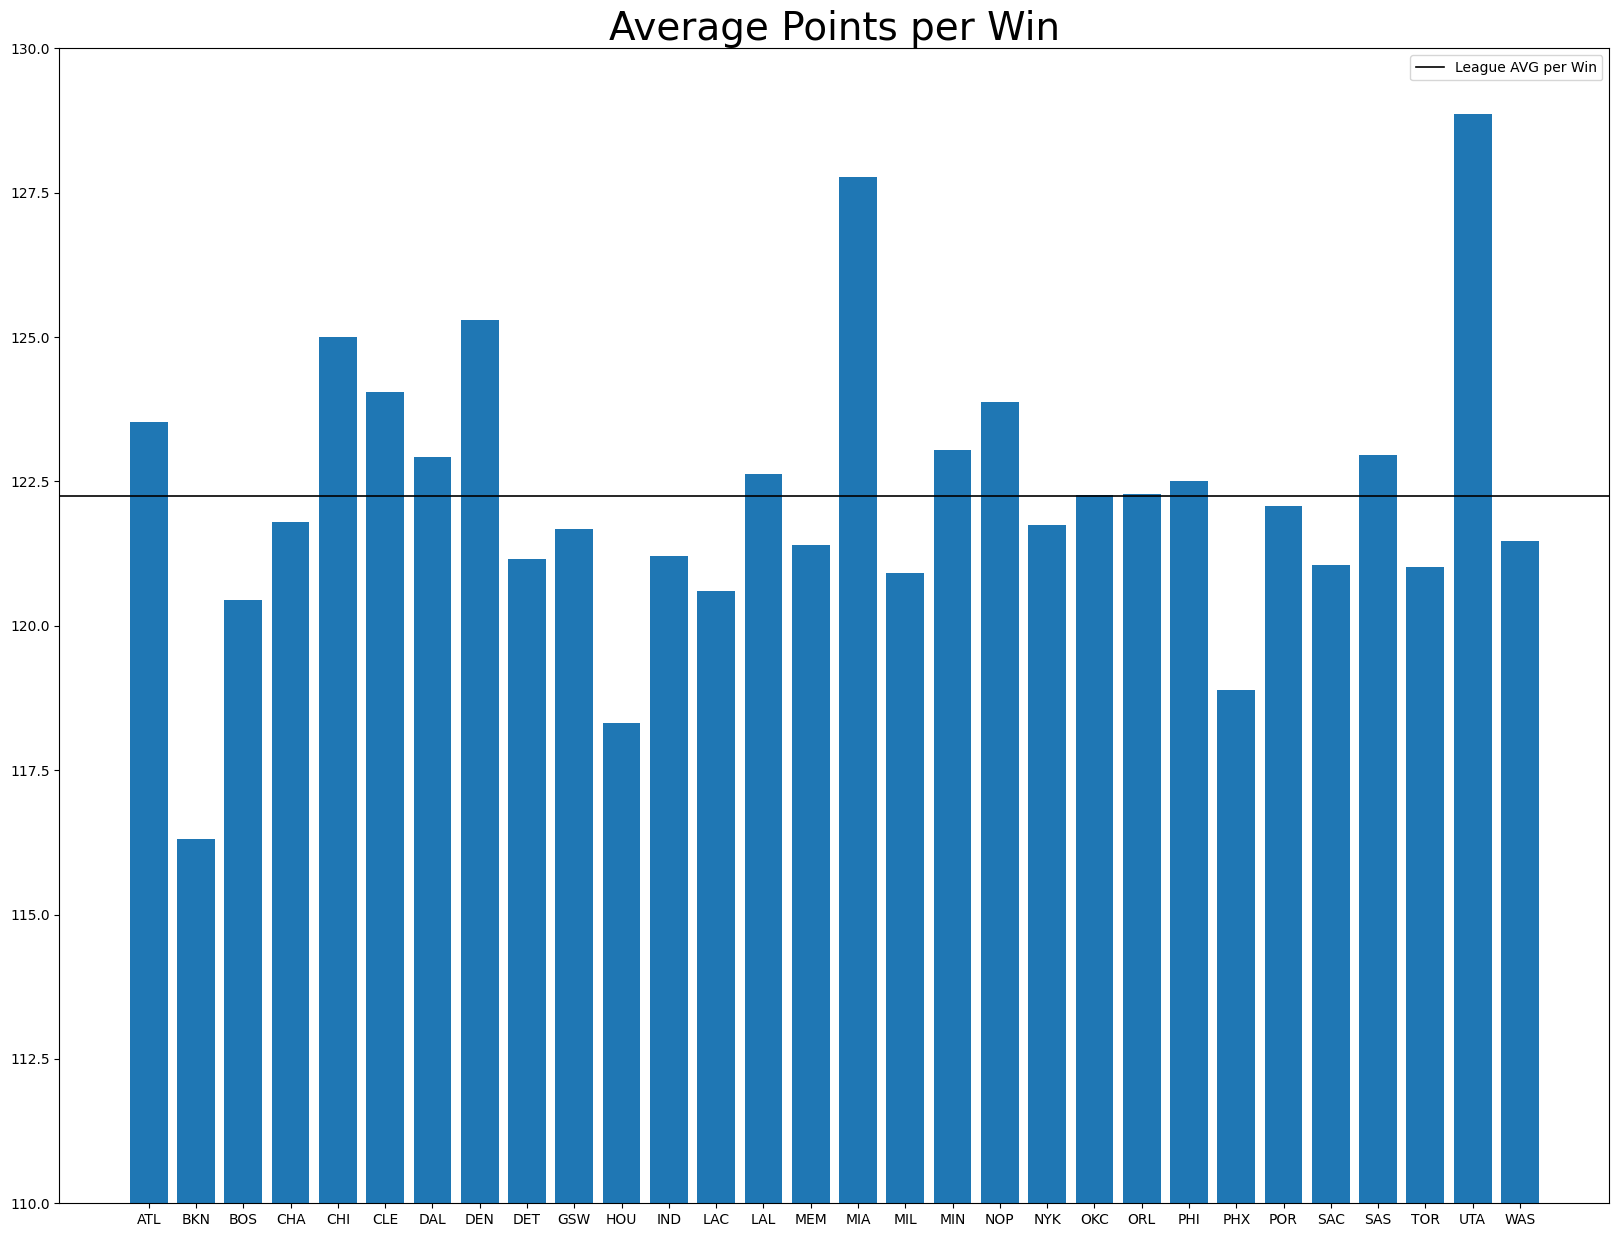

In [42]:
# create a figure and axis to plot a bar graph
fig, ax = plt.subplots(figsize =(20, 15))
# create and object for when plotting bar graph so that it can be looped through later. Bar graph consist of team and 'p_diff' and ronuded 2 places.
bars = ax.bar(wins_agg['teams'], round(wins_agg['points'], 2),) # color = '#17408B'

# league_win_avg = sum(wins_agg['points'])/len(wins_agg['points'])

ax.set_ylim(110,130)
plt.title("Average Points per Win", fontsize = 28)
plt.axhline(league_win_avg, color='black', linewidth=1.2, label = 'League AVG per Win') # Add a line at League Average points for wins for clarity
plt.legend()
plt.savefig('plots/points_per_win.png') # save figure off as a .png
plt.show()